In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Kütüphaneler yüklendi ✅")

Kütüphaneler yüklendi ✅


In [2]:
df = pd.read_csv(r'C:\Users\Cagatay\Desktop\project\customer-churn-prediction\data\WA_Fn-UseC_-Telco-Customer-Churn.csv')

print("Veri yüklendi ✅")
print(f"Satır sayısı: {df.shape[0]}")
print(f"Sütun sayısı: {df.shape[1]}")
df.head()

Veri yüklendi ✅
Satır sayısı: 7043
Sütun sayısı: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
# TotalCharges'ı sayıya çevir
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Oluşan NaN'ları sil
df = df.dropna()

print(f"Temizleme sonrası satır sayısı: {df.shape[0]}")

# Churn sütununu 1/0 yap
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print("Churn: Yes→1, No→0 ✅")
print(df['Churn'].value_counts())

Temizleme sonrası satır sayısı: 7032
Churn: Yes→1, No→0 ✅
Churn
0    5163
1    1869
Name: count, dtype: int64


In [5]:
# Kategorik sütunları bul
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols.remove('customerID')  # ID'yi çıkar, işimize yaramaz

print(f"Kategorik sütunlar: {cat_cols}")

Kategorik sütunlar: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [6]:
# Label Encoding uygula
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print("\nKategorik sütunlar sayıya çevrildi ✅")
df.head()


Kategorik sütunlar sayıya çevrildi ✅


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,0,0,1,0,1,0,1,0,0,...,0,0,0,0,0,1,2,29.85,29.85,0
1,5575-GNVDE,1,0,0,0,34,1,0,0,2,...,2,0,0,0,1,0,3,56.95,1889.50,0
2,3668-QPYBK,1,0,0,0,2,1,0,0,2,...,0,0,0,0,0,1,3,53.85,108.15,1
3,7795-CFOCW,1,0,0,0,45,0,1,0,2,...,2,2,0,0,1,0,0,42.30,1840.75,0
4,9237-HQITU,0,0,0,0,2,1,0,1,0,...,0,0,0,0,0,1,2,70.70,151.65,1


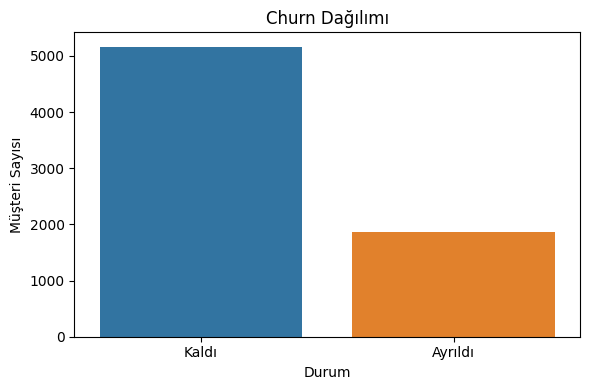

Kalan müşteri: 5163 (%73.4)
Ayrılan müşteri: 1869 (%26.6)


In [7]:
# Churn dağılımı
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn', hue='Churn', legend=False)
plt.title('Churn Dağılımı')
plt.xticks([0, 1], ['Kaldı', 'Ayrıldı'])
plt.xlabel('Durum')
plt.ylabel('Müşteri Sayısı')
plt.tight_layout()
plt.show()

print(f"Kalan müşteri: {df['Churn'].value_counts()[0]} (%{round(df['Churn'].value_counts()[0]/len(df)*100, 1)})")
print(f"Ayrılan müşteri: {df['Churn'].value_counts()[1]} (%{round(df['Churn'].value_counts()[1]/len(df)*100, 1)})")

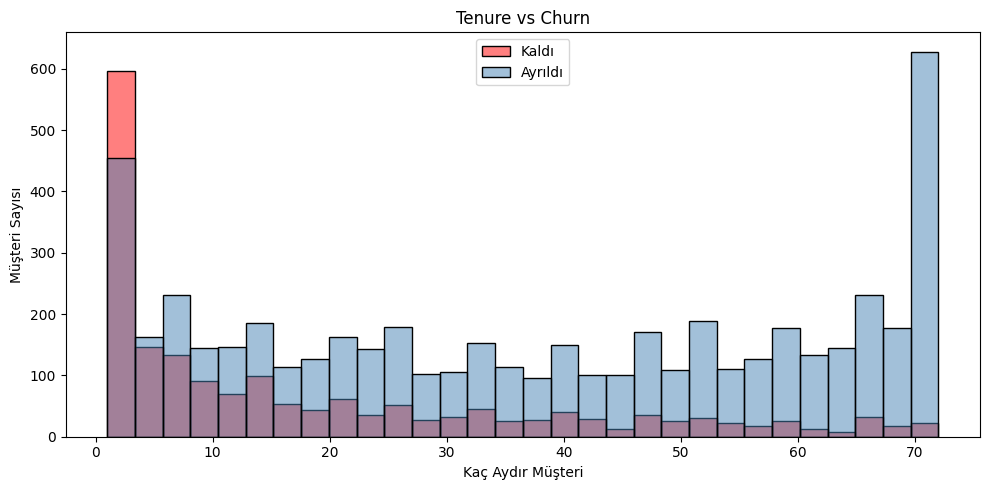

In [8]:
# Kaç aydır müşteri olanlar daha çok ayrılıyor?
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, palette=['steelblue', 'red'])
plt.title('Tenure vs Churn')
plt.xlabel('Kaç Aydır Müşteri')
plt.ylabel('Müşteri Sayısı')
plt.legend(['Kaldı', 'Ayrıldı'])
plt.tight_layout()
plt.show()

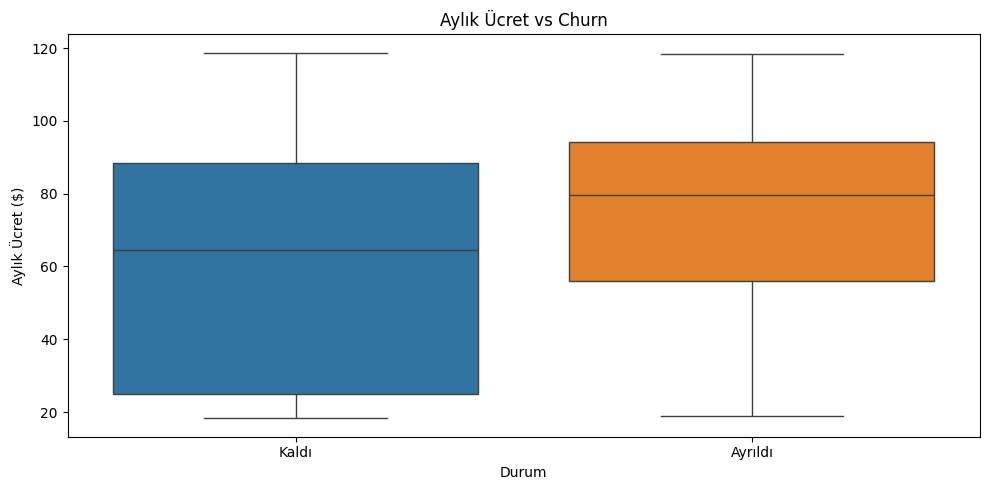

In [9]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', hue='Churn', legend=False)
plt.title('Aylık Ücret vs Churn')
plt.xticks([0, 1], ['Kaldı', 'Ayrıldı'])
plt.xlabel('Durum')
plt.ylabel('Aylık Ücret ($)')
plt.tight_layout()
plt.show()

In [10]:
# Feature'ları ve hedefi ayır
X = df.drop(['customerID', 'Churn'], axis=1)
y = df['Churn']

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train seti: {X_train.shape[0]} satır")
print(f"Test seti: {X_test.shape[0]} satır")

Train seti: 5625 satır
Test seti: 1407 satır


In [11]:
# Model 1: Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

# Model 2: Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("Modeller eğitildi ✅")

C:\Users\Cagatay\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Modeller eğitildi ✅


In [12]:
print("=" * 50)
print("LOGISTIC REGRESSION")
print("=" * 50)
print(f"Accuracy: {round(accuracy_score(y_test, lr_pred) * 100, 2)}%")
print(classification_report(y_test, lr_pred, target_names=['Kaldı', 'Ayrıldı']))

print("=" * 50)
print("RANDOM FOREST")
print("=" * 50)
print(f"Accuracy: {round(accuracy_score(y_test, rf_pred) * 100, 2)}%")
print(classification_report(y_test, rf_pred, target_names=['Kaldı', 'Ayrıldı']))

LOGISTIC REGRESSION
Accuracy: 78.75%
              precision    recall  f1-score   support

       Kaldı       0.83      0.89      0.86      1033
     Ayrıldı       0.63      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407

RANDOM FOREST
Accuracy: 79.25%
              precision    recall  f1-score   support

       Kaldı       0.83      0.90      0.86      1033
     Ayrıldı       0.64      0.49      0.56       374

    accuracy                           0.79      1407
   macro avg       0.74      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



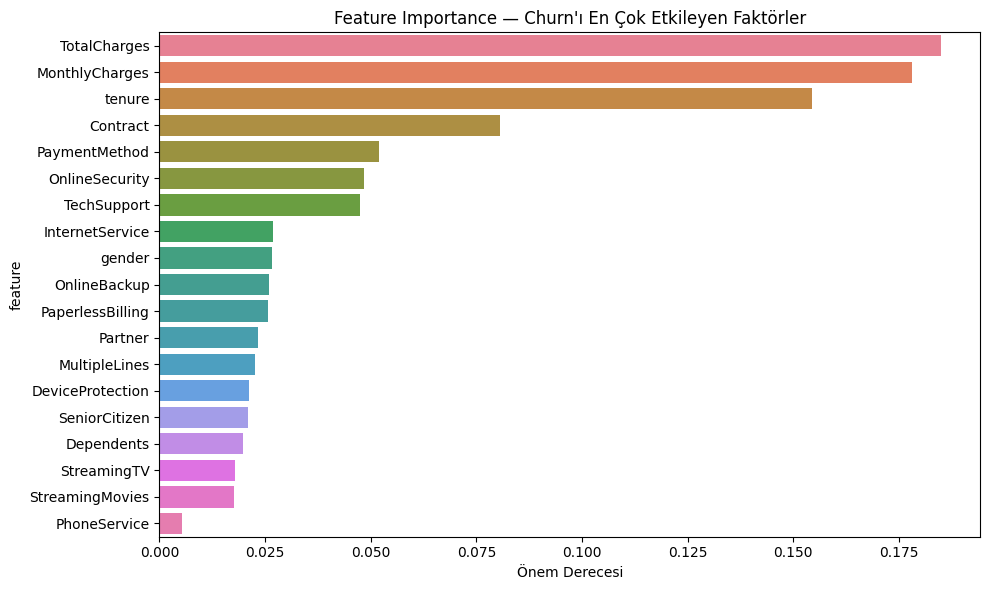

In [13]:
# Hangi sütun churn'ü en çok etkiliyor?
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='importance', y='feature', hue='feature', legend=False)
plt.title('Feature Importance — Churn\'ı En Çok Etkileyen Faktörler')
plt.xlabel('Önem Derecesi')
plt.tight_layout()
plt.show()